Descargando datos para 22 activos...


[*********************100%***********************]  22 of 22 completed


Iniciando simulación sobre 2680 días (EWMA=Activo)...
Procesado: 2017-05-12
Procesado: 2018-02-28
Procesado: 2018-12-13
Procesado: 2019-10-01
Procesado: 2020-07-17
Procesado: 2021-05-04
Procesado: 2022-02-16
Procesado: 2022-12-02
Procesado: 2023-09-21
Procesado: 2024-07-10
Procesado: 2025-04-28
Procesado: 2026-02-12

--- Métricas de Desempeño (CON EWMA λ=lambda_ewma) ---
                               CAGR  Vol (Ann)    Sharpe     MaxDD
Strategy                                                          
HRP Strategy (EWMA)       -0.000003   0.014760 -0.456859 -0.242759
Equal Weight (1/N) (EWMA) -0.000044   0.030880 -3.453655 -0.296866
SPY (Market) (EWMA)        0.000077   0.023607  7.929043 -0.337173


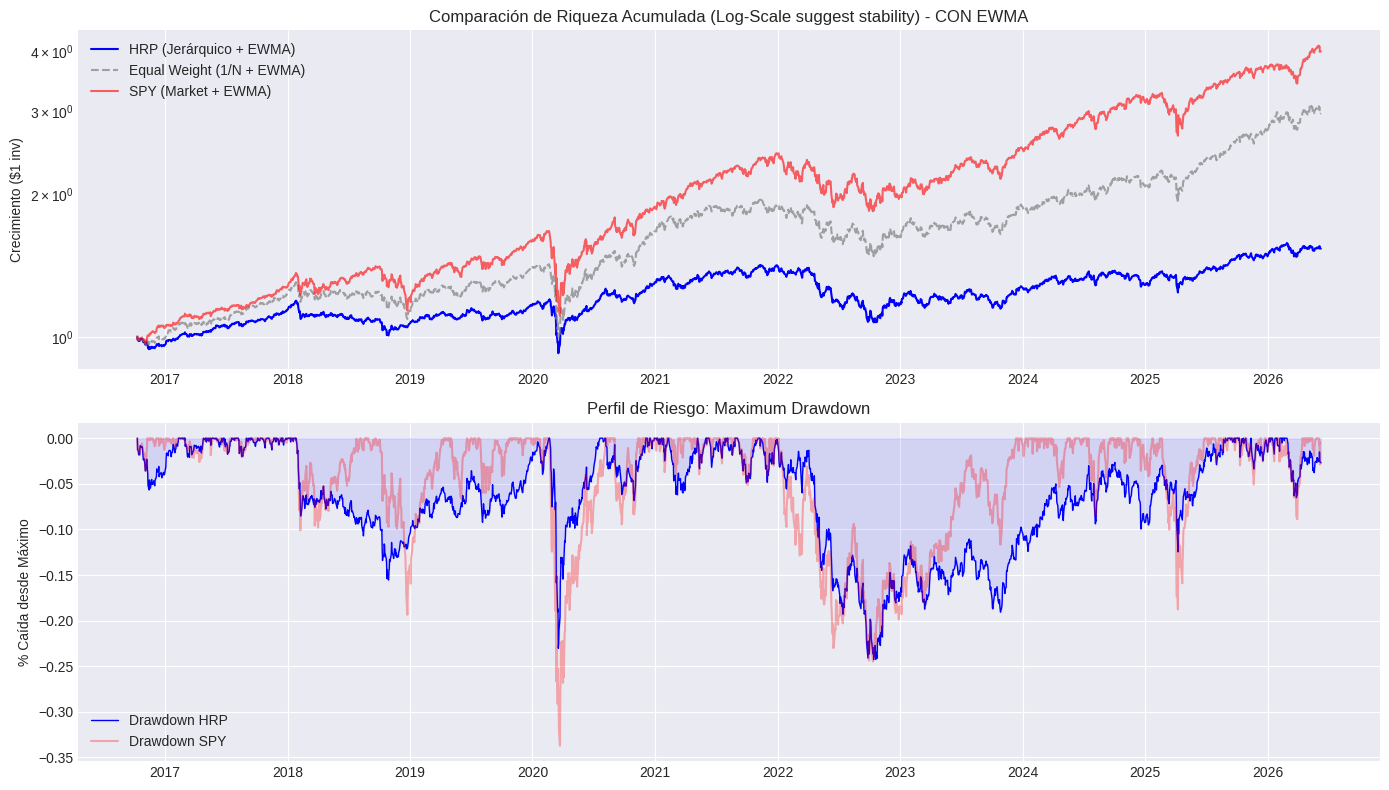


--- Estructura de Pesos EWMA (λ=lambda_ewma) ---
Peso máximo (más reciente): 0.050000
Peso mínimo (más antiguo): 0.000000
Ratio: 476937456378129018919300037252546880880914804306352896212992.00x


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import warnings

# Configuración académica
warnings.filterwarnings('ignore') # Ignorar warnings de versiones para limpieza en la tesis
plt.style.use('seaborn-v0_8-darkgrid')
lambda_ewma = 0.9

# ==========================================
# 0. FUNCIÓN AUXILIAR: EWMA WEIGHTING
# ==========================================
def apply_ewma_weights(returns_df, lambda_=lambda_ewma):
    """
    Aplica pesos EWMA a los retornos.
    Datos más recientes tienen mayor peso.
    
    Parámetro:
    - lambda_: factor de decaimiento (lambda_ewma es clásico, más cercano a 1 = menos decaimiento)
    - Retorna: DataFrame de retornos ponderados y array de pesos
    """
    n = len(returns_df)
    # Pesos: más reciente (final) tiene peso máximo
    # w_t = (1 - lambda) * lambda^(n-1-t)
    weights = (1 - lambda_) * (lambda_ ** np.arange(n)[::-1])
    weights = weights / weights.sum()  # Normalizar para que sumen 1
    
    # Aplicar pesos a cada retorno
    weighted_returns = returns_df.mul(weights, axis=0)
    
    return weighted_returns, weights

# ==========================================
# 1. SELECCIÓN DEL UNIVERSO (El Sistema)
# ==========================================
tickers = [
    'SPY', 'QQQ', 'DIA', 'IWM',       # US Broad / Tech / Industrial
    'EEM', 'FXI', 'EWZ', 'IEUR', 'EFA', # Emerging / Brazil / Europe / Developed
    'ACWI',                    # All World
    'ARKK',                    # High Beta / Innovation (Ruido alto)
    'XLE', 'XLV', 'XLF',       # Energy / Health / Finance
    'GLD', 'URA', 'SLV',                    # Gold (Safe Haven / Inflation hedge)
    'XLRE', 'TLT', 'DBC', 'EDV', 'AIA'                      # Real Esta
] #'ITA'
#NO EEUU
# tickers = [
#     'EEM', 'FXI', 'EWZ', 'IEUR', 'EFA', # Emerging / Brazil / Europe / Developed
#     'GLD', 'URA', 'SLV',                    # Gold (Safe Haven / Inflation hedge)
#     'DBC', 'AIA',    
# ] 
# ==========================================
# 2. MOTOR FÍSICO (HRP LOGIC)
# ==========================================
def getIVP(cov, **kargs):
    """Inverse Variance Portfolio (Caso límite de mínima energía)."""
    ivp = 1. / np.diag(cov)
    ivp /= ivp.sum()
    return ivp

def getClusterVar(cov, cItems):
    """Calcula la varianza interna del cluster."""
    cov_slice = cov.loc[cItems, cItems]
    w = getIVP(cov_slice).reshape(-1, 1)
    cVar = np.dot(np.dot(w.T, cov_slice), w)[0, 0]
    return cVar

def getQuasiDiag(link):
    """Organiza la matriz para revelar la estructura jerárquica."""
    link = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3]
    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0] * 2, 2)
        df0 = sortIx[sortIx >= numItems]
        i = df0.index
        j = df0.values - numItems
        sortIx[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i + 1)
        sortIx = pd.concat([sortIx, df0])
        sortIx = sortIx.sort_index()
        sortIx.index = range(sortIx.shape[0])
    return sortIx.tolist()

def getRecBipart(cov, sortIx):
    """Asignación de pesos por bisección recursiva."""
    w = pd.Series(1.0, index=sortIx)
    cItems = [sortIx]
    while len(cItems) > 0:
        cItems = [i[j:k] for i in cItems for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(cItems), 2):
            cItems0 = cItems[i]
            cItems1 = cItems[i + 1]
            cVar0 = getClusterVar(cov, cItems0)
            cVar1 = getClusterVar(cov, cItems1)
            alpha = 1 - cVar0 / (cVar0 + cVar1)
            w.loc[cItems0] *= alpha
            w.loc[cItems1] *= (1 - alpha)
    return w

def hrp_optimization(returns, use_ewma=True, lambda_=lambda_ewma):
    """
    Función Wrapper para el proceso completo.
    Si use_ewma=True, usa retornos ponderados por EWMA.
    """
    # Aplicar pesos EWMA si se solicita
    if use_ewma:
        returns_weighted, _ = apply_ewma_weights(returns, lambda_=lambda_)
        cov = returns_weighted.cov()
        corr = returns_weighted.corr()
    else:
        cov = returns.cov()
        corr = returns.corr()
    
    # Distancia basada en correlación (Métrica de Mantegna)
    # d(i,j) = sqrt(0.5 * (1 - rho(i,j)))
    dist = np.sqrt(0.5 * (1 - corr))
    dist_condensed = sch.distance.pdist(dist, 'euclidean')
    
    # Clustering Jerárquico (Single Linkage preserva estructura MST)
    link = sch.linkage(dist_condensed, 'single')
    
    sortIx = getQuasiDiag(link)
    sortIx = corr.index[sortIx].tolist()
    
    hrp_weights = getRecBipart(cov, sortIx)
    return hrp_weights.sort_index()

# ==========================================
# 3. DATA FETCHING & PREPROCESSING
# ==========================================
print(f"Descargando datos para {len(tickers)} activos...")
data = yf.download(tickers, start="2010-01-01", auto_adjust=False)['Adj Close']
data = data.dropna() # Eliminar días sin cotización completa

# Retornos Logarítmicos (Propiedad aditiva para análisis físico)
log_rets = np.log(data / data.shift(1)).dropna()


# ==========================================
# 4. BACKTEST WALK-FORWARD (El Experimento)
# ==========================================
def run_backtest(returns_df, lookback=252, rebalance_freq=21, tx_cost=0.005, use_ewma=True, lambda_=lambda_ewma):
    """
    tx_cost: 0.001 = 10 basis points por transacción (compra+venta)
    use_ewma: aplicar pesos EWMA en la ventana de entrenamiento
    """
    dates = returns_df.index
    n_days = len(dates)
    
    # Almacenamiento
    weights_hrp = []
    rets_hrp = []
    rets_eq = [] # Benchmark 1/N
    
    # Pesos iniciales
    w_curr_hrp = pd.Series(1.0/returns_df.shape[1], index=returns_df.columns)
    
    print(f"Iniciando simulación sobre {n_days} días (EWMA={'Activo' if use_ewma else 'Inactivo'})...")
    
    for t in range(lookback, n_days):
        curr_date = dates[t]
        
        # 1. Rebalanceo
        if (t - lookback) % rebalance_freq == 0:
            train_window = returns_df.iloc[t-lookback:t]
            
            # Calcular nuevos pesos HRP (con EWMA si se solicita)
            w_new_hrp = hrp_optimization(train_window, use_ewma=use_ewma, lambda_=lambda_)
            
            # Costo de Transacción: |w_new - w_old| * costo
            turnover = np.sum(np.abs(w_new_hrp - w_curr_hrp))
            cost = turnover * tx_cost
            
            w_curr_hrp = w_new_hrp
        else:
            cost = 0.0
            
        # 2. Calcular Retorno del día t (Out of Sample)
        # Retorno simple del activo para el PnL
        day_asset_rets = np.exp(returns_df.iloc[t]) - 1
        
        # HRP Return
        port_ret_hrp = np.sum(w_curr_hrp * day_asset_rets) - cost
        rets_hrp.append(port_ret_hrp)
        
        # Equal Weight Return (Benchmark de Entropía Máxima)
        w_eq = np.ones(len(tickers)) / len(tickers)
        # Asumimos rebalanceo diario implícito o drift para 1/N, simplificado aquí:
        port_ret_eq = np.mean(day_asset_rets) 
        rets_eq.append(port_ret_eq)
        
        if t % 200 == 0: print(f"Procesado: {curr_date.date()}")

    return pd.Series(rets_hrp, index=dates[lookback:]), pd.Series(rets_eq, index=dates[lookback:])

# Ejecutar Backtest con EWMA
hrp_results, eq_results = run_backtest(log_rets, lookback=252, rebalance_freq=21, tx_cost=0.005, use_ewma=True, lambda_=lambda_ewma)

# Benchmark de Mercado (SPY)
spy_rets = (np.exp(log_rets['SPY']) - 1).loc[hrp_results.index]

# ==========================================
# 5. ANÁLISIS DE RESULTADOS & FÍSICA (CON EWMA)
# ==========================================
def calculate_metrics(series, name, use_ewma=True, lambda_=lambda_ewma):
    """
    Calcula métricas ponderadas por EWMA si use_ewma=True.
    """
    cum_ret = (1 + series).cumprod()
    
    if use_ewma:
        # Aplicar pesos EWMA a los retornos
        series_weighted, weights_ewma = apply_ewma_weights(series, lambda_=lambda_)
        
        # Retorno promedio ponderado
        mean_ret = series_weighted.sum()
        
        # Volatilidad ponderada (desv. estándar de retornos ponderados)
        var_weighted = (series_weighted ** 2).sum()
        vol = np.sqrt(var_weighted) * np.sqrt(252)
        
        # CAGR con pesos EWMA (usar cum_ret pero calcular de forma ponderada)
        cagr = (1 + series_weighted.sum()) ** (252 / len(series)) - 1
        
        # Sharpe ponderado
        sharpe = (mean_ret / np.sqrt(var_weighted)) * np.sqrt(252)
    else:
        # Sin EWMA (cálculo tradicional)
        cagr = cum_ret.iloc[-1]**(252/len(series)) - 1
        vol = series.std() * np.sqrt(252)
        sharpe = (series.mean() / series.std()) * np.sqrt(252)
    
    # Max Drawdown (sin ponderar, es una métrica de riesgo extremo)
    dd = (cum_ret / cum_ret.cummax() - 1)
    max_dd = dd.min()
    
    return [name, cagr, vol, sharpe, max_dd]

metrics = []
metrics.append(calculate_metrics(hrp_results, 'HRP Strategy (EWMA)', use_ewma=True, lambda_=lambda_ewma))
metrics.append(calculate_metrics(eq_results, 'Equal Weight (1/N) (EWMA)', use_ewma=True, lambda_=lambda_ewma))
metrics.append(calculate_metrics(spy_rets, 'SPY (Market) (EWMA)', use_ewma=True, lambda_=lambda_ewma))

df_metrics = pd.DataFrame(metrics, columns=['Strategy', 'CAGR', 'Vol (Ann)', 'Sharpe', 'MaxDD']).set_index('Strategy')

print("\n--- Métricas de Desempeño (CON EWMA λ=lambda_ewma) ---")
print(df_metrics)

# ==========================================
# 6. VISUALIZACIÓN
# ==========================================
# Curva de Equidad
cum_hrp = (1 + hrp_results).cumprod()
cum_eq = (1 + eq_results).cumprod()
cum_spy = (1 + spy_rets).cumprod()

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(cum_hrp, label='HRP (Jerárquico + EWMA)', color='blue', linewidth=1.5)
plt.plot(cum_eq, label='Equal Weight (1/N + EWMA)', color='gray', linestyle='--', alpha=0.7)
plt.plot(cum_spy, label='SPY (Market + EWMA)', color='red', alpha=0.6)
plt.title('Comparación de Riqueza Acumulada (Log-Scale suggest stability) - CON EWMA')
plt.ylabel('Crecimiento ($1 inv)')
plt.legend()
plt.yscale('log') # Escala logarítmica para ver mejor las tasas de crecimiento constantes

# Drawdowns (La "Profundidad del Pozo")
dd_hrp = (cum_hrp / cum_hrp.cummax() - 1)
dd_spy = (cum_spy / cum_spy.cummax() - 1)

plt.subplot(2, 1, 2)
plt.plot(dd_hrp, label='Drawdown HRP', color='blue', linewidth=1)
plt.plot(dd_spy, label='Drawdown SPY', color='red', alpha=0.3)
plt.fill_between(dd_hrp.index, dd_hrp, 0, color='blue', alpha=0.1)
plt.title('Perfil de Riesgo: Maximum Drawdown')
plt.ylabel('% Caída desde Máximo')
plt.legend()

plt.tight_layout()
plt.show()

# Visualización de Pesos EWMA (referencia)
print("\n--- Estructura de Pesos EWMA (λ=lambda_ewma) ---")
_, ewma_weights = apply_ewma_weights(log_rets, lambda_=lambda_ewma)
print(f"Peso máximo (más reciente): {ewma_weights[-1]:.6f}")
print(f"Peso mínimo (más antiguo): {ewma_weights[0]:.6f}")
print(f"Ratio: {ewma_weights[-1] / ewma_weights[0]:.2f}x")

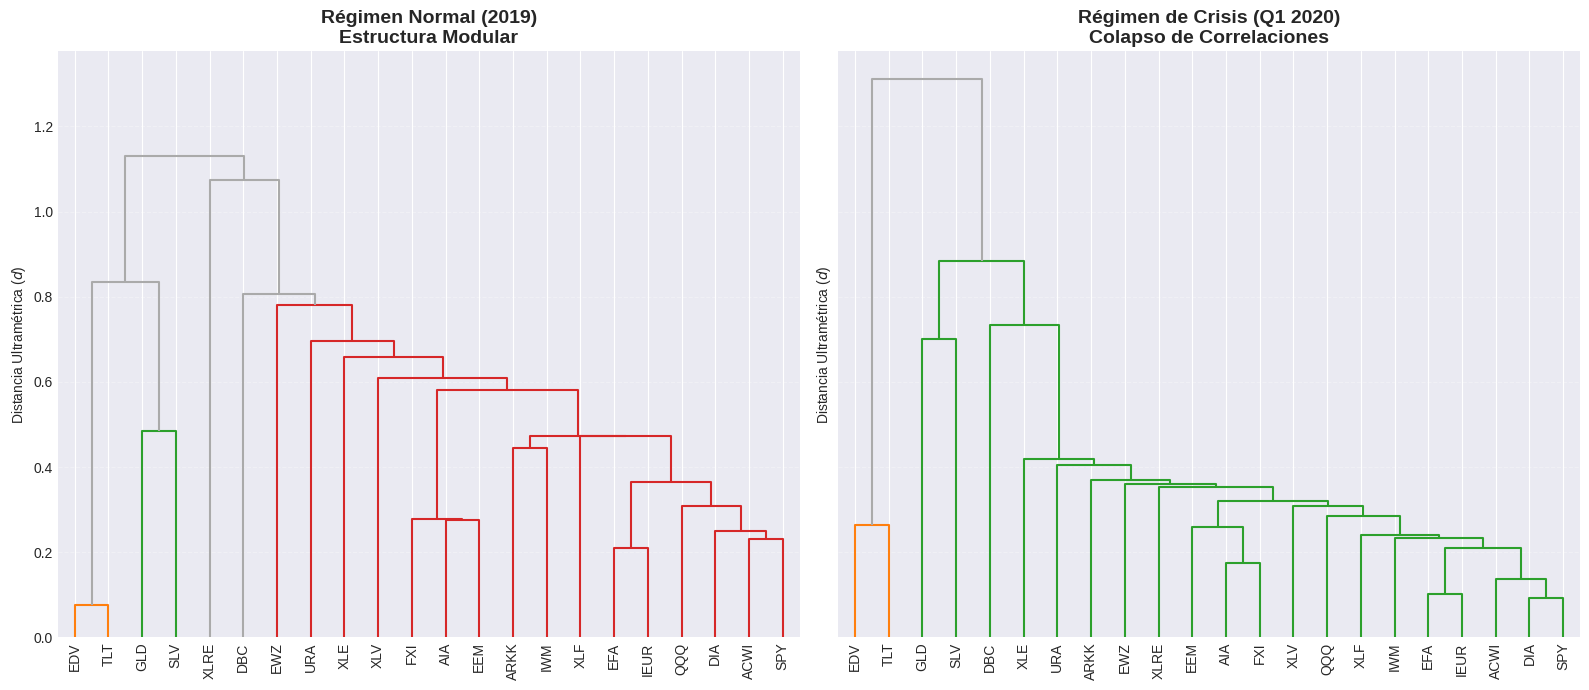

In [42]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

def plot_market_topology(returns_df, start_date, end_date, ax, title):
    """
    Genera el dendrograma (MST proyectado) para un periodo específico.
    """
    # 1. Slice de datos para el periodo
    period_data = returns_df.loc[start_date:end_date]
    
    if period_data.empty:
        print(f"Error: No hay datos para {title}")
        return

    # 2. Cálculo de la Métrica de Distancia (Mantegna)
    # d(i,j) = sqrt(2 * (1 - rho_ij))
    # Nota: Usamos 2*(...) para escalar a 0-2, o 0.5 para 0-1. 
    # Mantendremos consistencia con el código HRP previo (0.5).
    corr = period_data.corr()
    dist = np.sqrt(0.5 * (1 - corr))
    
    # 3. Clustering Jerárquico
    # 'Single linkage' es crucial para preservar la propiedad de MST (Minimum Spanning Tree)
    dist_condensed = sch.distance.pdist(dist, 'euclidean')
    linkage_matrix = sch.linkage(dist_condensed, method='single')
    
    # 4. Plotting
    sch.dendrogram(
        linkage_matrix,
        labels=period_data.columns,
        ax=ax,
        leaf_rotation=90,
        leaf_font_size=10,
        above_threshold_color='#AAAAAA' # Color de las uniones altas
    )
    
    # Estética Académica
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_ylabel('Distancia Ultramétrica ($d$)', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# --- Configuración del Experimento "Rotura de Simetría" ---

# Definimos dos regímenes termodinámicos distintos:
# Régimen A: Calma / Baja Volatilidad (2019 Completo)
p1_start, p1_end = '2019-01-01', '2019-12-31'

# Régimen B: Choque Exógeno / Alta Volatilidad (COVID Q1 2020)
p2_start, p2_end = '2020-01-01', '2020-04-30'

# Crear la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Generar los gráficos
plot_market_topology(log_rets, p1_start, p1_end, ax1, f'Régimen Normal (2019)\nEstructura Modular')
plot_market_topology(log_rets, p2_start, p2_end, ax2, f'Régimen de Crisis (Q1 2020)\nColapso de Correlaciones')

plt.tight_layout()
plt.show()

Reconstruyendo historial de pesos...


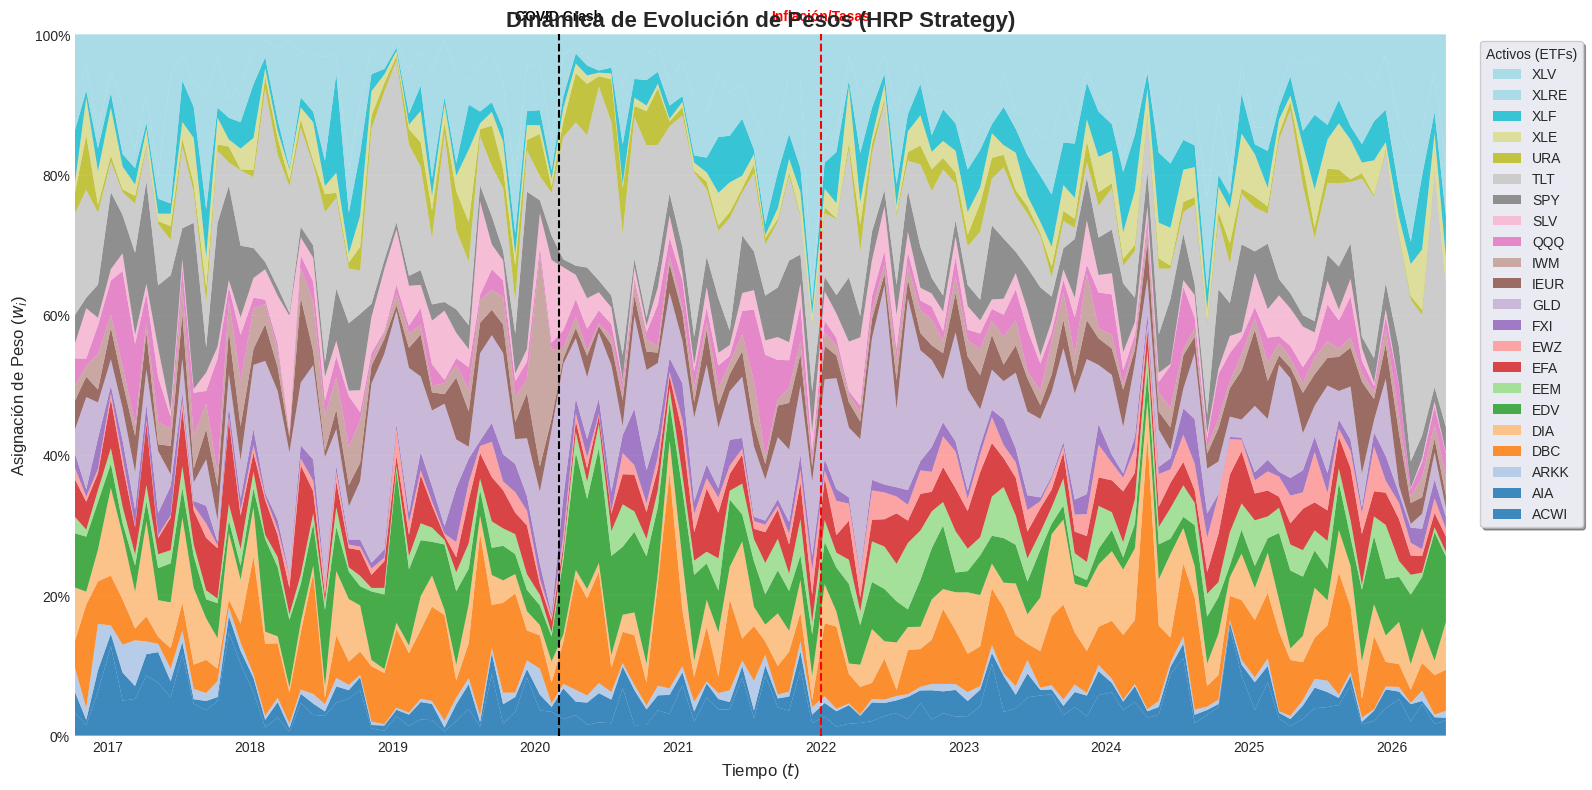

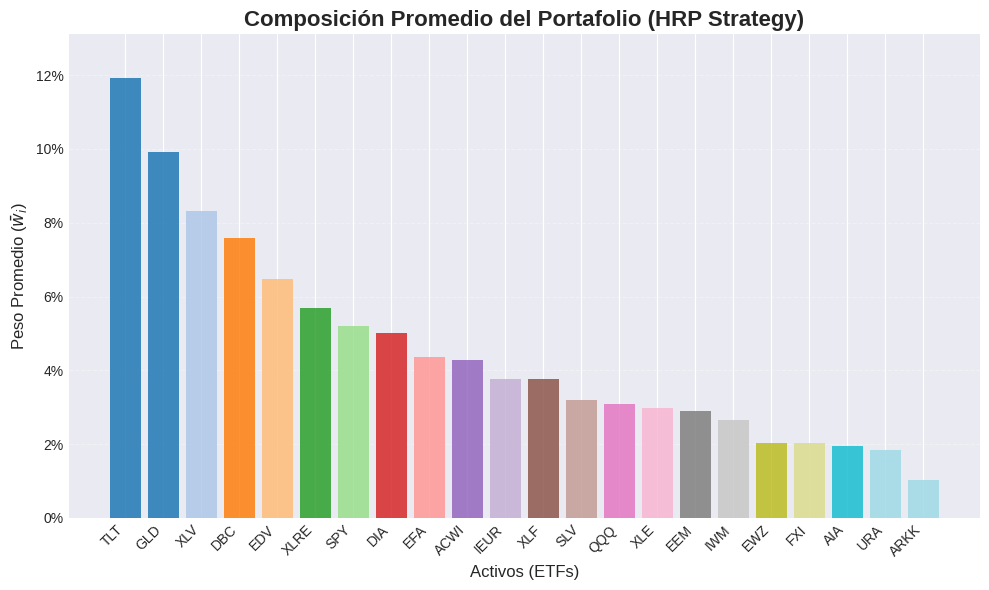

In [43]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np

# 1. Regenerar la Historia de Pesos
# (Repetimos el loop del backtest solo para extraer el DataFrame de pesos)

def get_weights_history(returns_df, lookback=252, rebalance_freq=21):
    dates = returns_df.index
    n_days = len(dates)
    weights_history = []
    rebalance_dates = []
    
    # Peso inicial dummy (equiponderado)
    current_weights = pd.Series(1.0/returns_df.shape[1], index=returns_df.columns)
    
    print("Reconstruyendo historial de pesos...")
    
    for t in range(lookback, n_days):
        # Solo guardamos datos en fechas de rebalanceo para no saturar el gráfico
        if (t - lookback) % rebalance_freq == 0:
            train_window = returns_df.iloc[t-lookback:t]
            current_weights = hrp_optimization(train_window)
            
            weights_history.append(current_weights)
            rebalance_dates.append(dates[t])
            
    return pd.DataFrame(weights_history, index=rebalance_dates)

# Ejecutamos la reconstrucción
df_weights = get_weights_history(log_rets, lookback=252, rebalance_freq=21)

# 2. Visualización: Stacked Area Chart
def plot_portfolio_composition(weights_df):
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Paleta de colores distintiva (tab20 es buena para >10 activos)
    colors = plt.cm.tab20(np.linspace(0, 1, len(weights_df.columns)))
    
    # Gráfico de áreas apiladas
    ax.stackplot(weights_df.index, weights_df.T, labels=weights_df.columns, colors=colors, alpha=0.85)
    
    # Estética Académica
    ax.set_title('Dinámica de Evolución de Pesos (HRP Strategy)', fontsize=16, weight='bold')
    ax.set_ylabel('Asignación de Peso ($w_i$)', fontsize=12)
    ax.set_xlabel('Tiempo ($t$)', fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.set_xlim(weights_df.index[0], weights_df.index[-1])
    
    # Formato de porcentaje en el eje Y
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.0%}".format(x)))
    
    # Leyenda externa (para no tapar datos)
    # Ordenamos la leyenda para que coincida visualmente con las pilas (invertir orden)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc='upper left', bbox_to_anchor=(1.02, 1), 
              title="Activos (ETFs)", frameon=True, shadow=True)
    
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    # 3. Anotaciones de Eventos de Mercado (Fenomenología)
    # Ajusta estas fechas según tu data real
    events = [
        ('2020-03-01', 'COVID Crash', 'black'),
        ('2022-01-01', 'Inflación/Tasas', 'red')
    ]
    
    for date, label, color in events:
        if pd.to_datetime(date) in weights_df.index or (pd.to_datetime(date) > weights_df.index[0] and pd.to_datetime(date) < weights_df.index[-1]):
            ax.axvline(pd.to_datetime(date), color=color, linestyle='--', linewidth=1.5)
            ax.text(pd.to_datetime(date), 1.02, label, color=color, ha='center', weight='bold')

    plt.tight_layout()
    plt.show()

plot_portfolio_composition(df_weights)

# Show Average Weights
def plot_avg_weights(weights_df):
    avg_weights = weights_df.mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Paleta de colores distintiva
    colors = plt.cm.tab20(np.linspace(0, 1, len(weights_df.columns)))
    
    # Gráfico de barras ordenado por peso
    ax.bar(range(len(avg_weights)), avg_weights.values, color=colors, alpha=0.85)
    
    # Estética Académica
    ax.set_title('Composición Promedio del Portafolio (HRP Strategy)', fontsize=16, weight='bold')
    ax.set_ylabel('Peso Promedio ($\\bar{w}_i$)', fontsize=12)
    ax.set_xlabel('Activos (ETFs)', fontsize=12)
    ax.set_ylim(0, avg_weights.max() * 1.1)
    ax.set_xticks(range(len(avg_weights)))
    ax.set_xticklabels(avg_weights.index, rotation=45, ha='right')
    
    # Formato de porcentaje en el eje Y
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.0%}".format(x)))
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_avg_weights(df_weights)

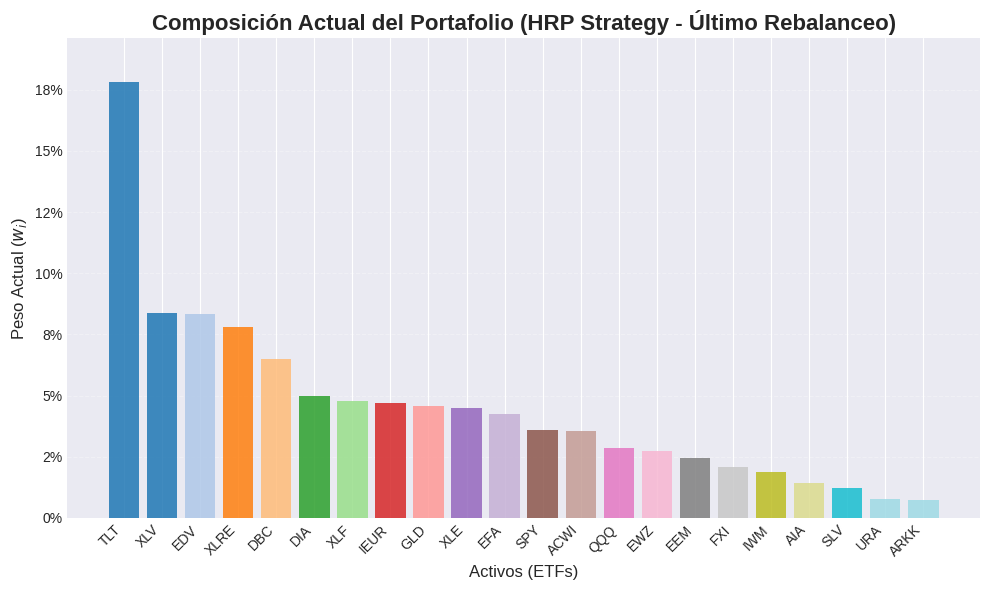


--- Composición Actual Recomendada (HRP) ---
TLT     0.178223
XLV     0.083901
EDV     0.083273
XLRE    0.078263
DBC     0.064779
DIA     0.049807
XLF     0.047783
IEUR    0.047108
GLD     0.045727
XLE     0.044892
EFA     0.042545
SPY     0.036079
ACWI    0.035581
QQQ     0.028682
EWZ     0.027194
EEM     0.024625
FXI     0.020940
IWM     0.018760
AIA     0.014286
SLV     0.012323
URA     0.007906
ARKK    0.007324

Fecha del último rebalanceo: 2026-05-20


In [44]:
# Show Last Weights
def plot_last_weights(weights_df):
    last_weights = weights_df.tail(12).mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Paleta de colores distintiva
    colors = plt.cm.tab20(np.linspace(0, 1, len(weights_df.columns)))
    
    # Gráfico de barras ordenado por peso
    ax.bar(range(len(last_weights)), last_weights.values, color=colors, alpha=0.85)
    
    # Estética Académica
    ax.set_title('Composición Actual del Portafolio (HRP Strategy - Último Rebalanceo)', fontsize=16, weight='bold')
    ax.set_ylabel('Peso Actual ($w_i$)', fontsize=12)
    ax.set_xlabel('Activos (ETFs)', fontsize=12)
    ax.set_ylim(0, last_weights.max() * 1.1)
    ax.set_xticks(range(len(last_weights)))
    ax.set_xticklabels(last_weights.index, rotation=45, ha='right')
    
    # Formato de porcentaje en el eje Y
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.0%}".format(x)))
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabla de valores
    print("\n--- Composición Actual Recomendada (HRP) ---")
    print(last_weights.to_string())
    print(f"\nFecha del último rebalanceo: {weights_df.index[-1].date()}")

plot_last_weights(df_weights)

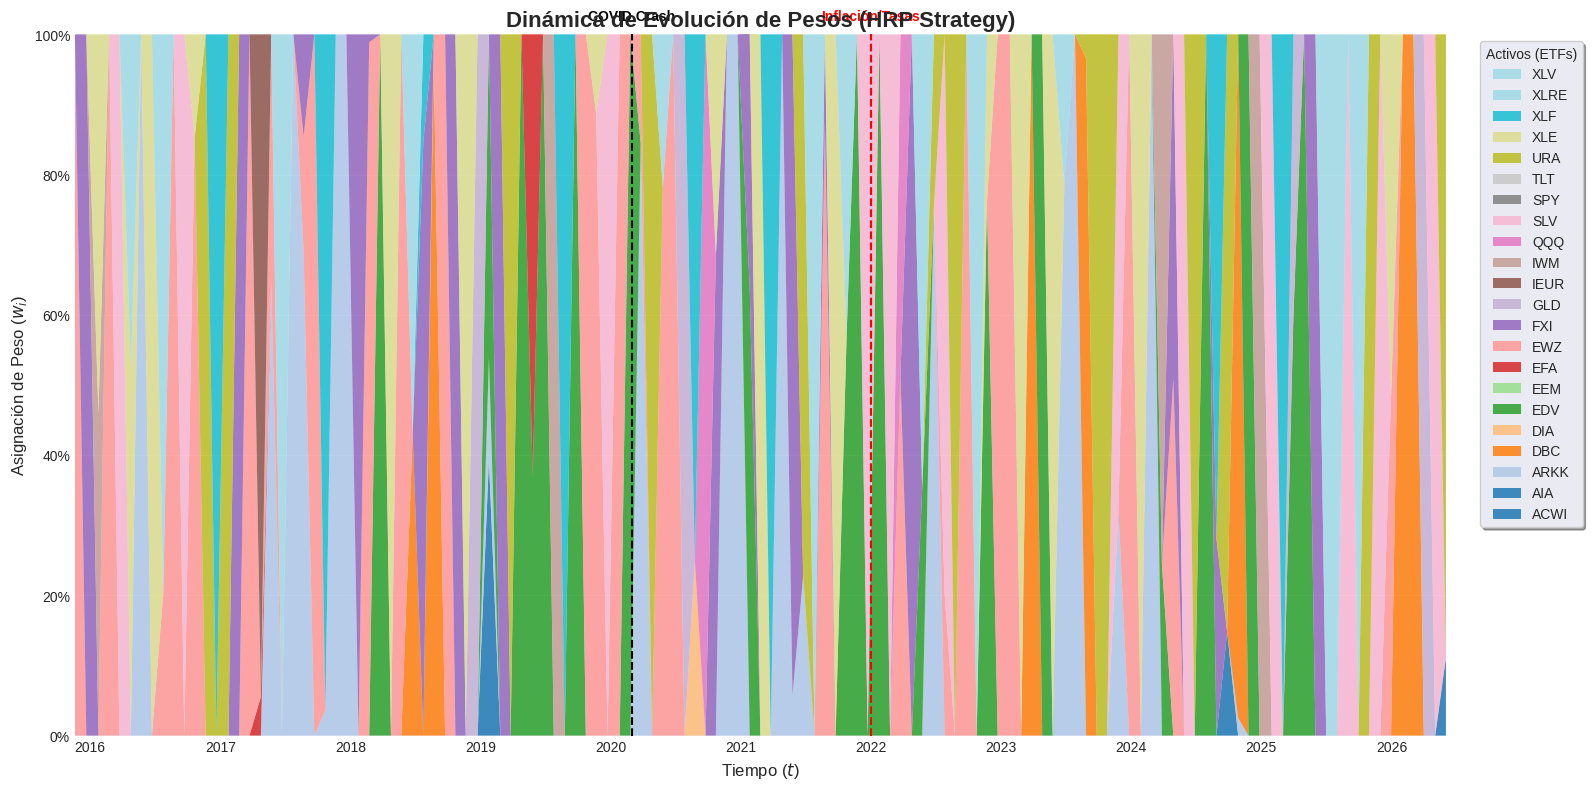

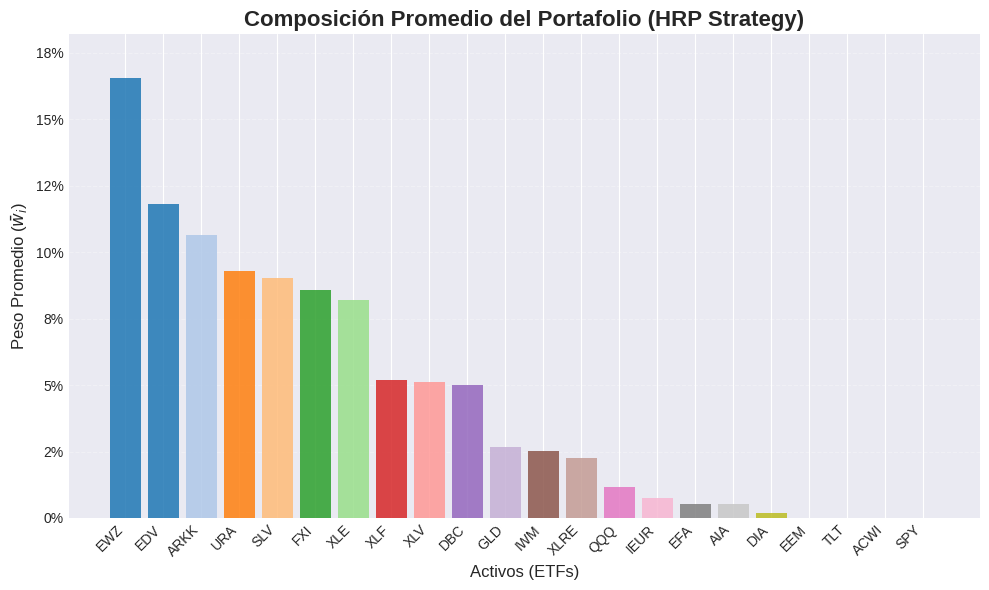

In [57]:
import scipy.optimize as sco
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster import hierarchy as sch
from sklearn.preprocessing import StandardScaler
lambda_ewma = 0.1

def hrp_optimization(returns, use_ewma=True, lambda_=0.94):
    """
    Función Wrapper para el proceso completo.
    Primero estandariza los retornos por ticker y luego aplica HRP.
    Así el portafolio se guía por correlaciones y no por volatilidad absoluta.
    """
    returns_standardized = pd.DataFrame(
        StandardScaler().fit_transform(returns),
        index=returns.index,
        columns=returns.columns
    )
    
    # Aplicar pesos EWMA si se solicita sobre retornos ya estandarizados
    if use_ewma:
        returns_weighted, _ = apply_ewma_weights(returns_standardized, lambda_=lambda_)
        cov = returns_weighted.cov()
        corr = returns_weighted.corr()
    else:
        cov = returns_standardized.cov()
        corr = returns_standardized.corr()
    
    # Distancia basada en correlación (Métrica de Mantegna)
    # d(i,j) = sqrt(0.5 * (1 - rho(i,j)))
    dist = np.sqrt(0.5 * (1 - corr))
    dist_condensed = sch.distance.pdist(dist, 'euclidean')
    
    # Clustering Jerárquico (Single Linkage preserva estructura MST)
    link = sch.linkage(dist_condensed, 'single')
    
    sortIx = getQuasiDiag(link)
    sortIx = corr.index[sortIx].tolist()
    
    hrp_weights = getRecBipart(cov, sortIx)
    return hrp_weights.sort_index()

# ==========================================
# SORTINO RATIO MAXIMIZATION FUNCTION
# ==========================================
def calculate_sortino_ratio(weights, returns_data, risk_free_rate=0.0, min_return=None):
    """
    Calcula el Sortino Ratio para un conjunto de pesos dado.
    
    Parámetros:
    - weights: array de pesos del portafolio
    - returns_data: DataFrame de retornos diarios
    - risk_free_rate: tasa libre de riesgo (anualizada)
    - min_return: retorno mínimo aceptable (threshold para downside). 
                  Si None, usa risk_free_rate/252
    
    Retorna: Sortino Ratio (anualizado)
    """
    if min_return is None:
        min_return = risk_free_rate / 252  # Convertir a retorno diario
    
    # Retorno del portafolio
    port_returns = returns_data @ weights
    
    # Retorno promedio anualizado
    annual_return = port_returns.mean() * 252
    
    # Downside Deviation (solo retornos por debajo del threshold)
    downside_returns = np.minimum(port_returns - min_return, 0)
    downside_std = np.sqrt(np.mean(downside_returns ** 2)) * np.sqrt(252)
    
    # Evitar división por cero
    if downside_std == 0:
        return 0.0
    
    sortino = (annual_return - risk_free_rate) / downside_std
    return sortino

def maximize_sortino_ratio(returns, use_ewma=False, lambda_=0.94, risk_free_rate=0.0):
    """
    Optimiza un portafolio para maximizar el Sortino Ratio.
    
    Parámetros:
    - returns: DataFrame de retornos diarios
    - use_ewma: aplicar pesos EWMA a los retornos históricos
    - lambda_: factor de decaimiento EWMA
    - risk_free_rate: tasa libre de riesgo (anualizada)
    
    Retorna: Series con pesos óptimos
    """
    # Aplicar pesos EWMA si se solicita
    if use_ewma:
        returns_weighted, _ = apply_ewma_weights(returns, lambda_=lambda_)
    else:
        returns_weighted = returns
    
    n_assets = returns_weighted.shape[1]
    
    # Función objetivo a MINIMIZAR (negativo del Sortino Ratio)
    def objective(w):
        sortino = calculate_sortino_ratio(w, returns_weighted, risk_free_rate=risk_free_rate)
        return -sortino  # Negativo porque minimizamos
    
    # Restricciones: pesos suman a 1
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    
    # Límites: cada peso entre 0 y 1 (sin short-selling)
    bounds = tuple((0, 1) for _ in range(n_assets))
    
    # Valor inicial: equiponderado
    x0 = np.array([1.0 / n_assets] * n_assets)
    
    # Optimización
    result = sco.minimize(
        objective,
        x0,
        method='SLSQP',  # Sequential Least Squares Programming
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-9, 'maxiter': 1000}
    )
    
    # Convertir a Series con los nombres de los activos
    optimal_weights = pd.Series(result.x, index=returns.columns)
    
    return optimal_weights

# ==========================================
# HRP + SORTINO RATIO HYBRID OPTIMIZATION
# ==========================================
def getClusterSortino(returns, cItems, risk_free_rate=0.0):
    """
    Calcula el Sortino Ratio interno del cluster optimizando pesos.
    Similar a getClusterVar pero usando Sortino en lugar de varianza.
    """
    returns_slice = returns[cItems]
    
    # Optimizar dentro del cluster
    n_assets = len(cItems)
    
    def objective(w):
        sortino = calculate_sortino_ratio(w, returns_slice, risk_free_rate=risk_free_rate)
        return -sortino
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = tuple((0, 1) for _ in range(n_assets))
    x0 = np.array([1.0 / n_assets] * n_assets)
    
    result = sco.minimize(objective, x0, method='SLSQP', bounds=bounds, 
                         constraints=constraints, options={'ftol': 1e-9, 'maxiter': 500})
    
    # Retornar el Sortino Ratio del cluster (positivo, mayor es mejor)
    sortino = -result.fun
    return sortino

def getRecBipartSortino(returns, sortIx, risk_free_rate=0.0):
    """
    Asignación de pesos por bisección recursiva usando Sortino Ratio.
    En lugar de balancear por varianza, balanceamos por Sortino Ratio.
    """
    w = pd.Series(1.0, index=sortIx)
    cItems = [sortIx]
    
    while len(cItems) > 0:
        cItems = [i[j:k] for i in cItems for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        
        for i in range(0, len(cItems), 2):
            cItems0 = cItems[i]
            cItems1 = cItems[i + 1]
            
            # Calcular Sortino de cada cluster
            sortino0 = getClusterSortino(returns, cItems0, risk_free_rate)
            sortino1 = getClusterSortino(returns, cItems1, risk_free_rate)
            
            # Alocar más peso al cluster con MAYOR Sortino
            # (inverso a HRP donde se aloca más al de menor varianza)
            total_sortino = sortino0 + sortino1
            
            if total_sortino > 0:
                alpha = sortino0 / total_sortino  # Mayor Sortino = mayor peso
            else:
                alpha = 0.5  # Si ambos son negativos, equiponderar
            
            w.loc[cItems0] *= alpha
            w.loc[cItems1] *= (1 - alpha)
    
    return w

def hrp_sortino_optimization(returns, use_ewma=True, lambda_=0.94, risk_free_rate=0.0):
    """
    HRP con Sortino Ratio: Usa la estructura jerárquica de HRP pero 
    optimiza usando Sortino Ratio en lugar de varianza.
    
    Parámetros:
    - returns: DataFrame de retornos
    - use_ewma: aplicar pesos EWMA
    - lambda_: factor de decaimiento EWMA
    - risk_free_rate: tasa libre de riesgo (anualizada)
    
    Retorna: Series con pesos óptimos
    """
    # Aplicar pesos EWMA si se solicita
    if use_ewma:
        returns_weighted, _ = apply_ewma_weights(returns, lambda_=lambda_)
        corr = returns_weighted.corr()
    else:
        returns_weighted = returns
        corr = returns.corr()
    
    # Clustering Jerárquico (igual que HRP estándar)
    dist = np.sqrt(0.5 * (1 - corr))
    dist_condensed = sch.distance.pdist(dist, 'euclidean')
    link = sch.linkage(dist_condensed, 'single')
    
    sortIx = getQuasiDiag(link)
    sortIx = corr.index[sortIx].tolist()
    
    # Bisección recursiva con Sortino
    hrp_sortino_weights = getRecBipartSortino(returns_weighted, sortIx, risk_free_rate)
    
    return hrp_sortino_weights.sort_index()

#Find optimal weights for rolling windows

df_weights = []
rebalance_dates = []
lookback = 30#252
rebalance_freq = 21
for t in range(lookback, len(log_rets)):
    if (t - lookback) % rebalance_freq == 0:
        train_window = log_rets.iloc[t-lookback:t]
        optimal_w = maximize_sortino_ratio(train_window, use_ewma=True, lambda_=lambda_ewma, risk_free_rate=0.01)
        df_weights.append(optimal_w)
        rebalance_dates.append(log_rets.index[t])

df_weights = pd.DataFrame(df_weights, index=rebalance_dates)

#Plotear la evolución de los pesos óptimos
plot_portfolio_composition(df_weights)
plot_avg_weights(df_weights)



--- Métricas de Desempeño (HRP Sortino-Optimized) ---
                                  CAGR  Vol (Ann)     Sharpe     MaxDD
Strategy                                                              
HRP Sortino-Optimized (EWMA)  0.000062   0.004799  31.355470 -0.288069
Equal Weight (1/N) (EWMA)     0.000072   0.004861  36.137593 -0.296866
SPY (Market) (EWMA)           0.000077   0.005007  37.318755 -0.337173


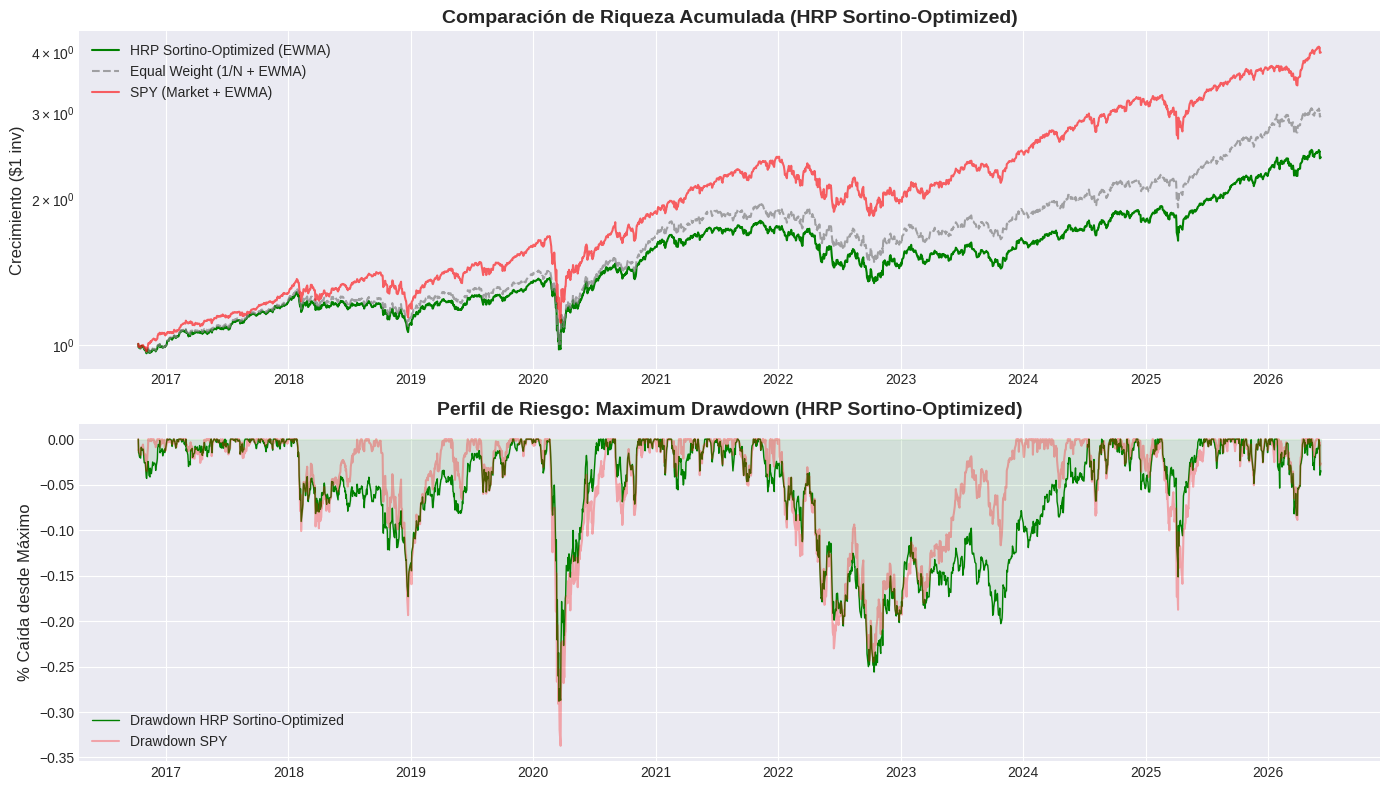

In [58]:
lambda_ewma = 0.998  # Factor de decaimiento para EWMA (ajustable según preferencia)
# Create a backtest function for the Sortino-optimized portfolio
def run_backtest_sortino(returns_df, lookback=252, rebalance_freq=21, tx_cost=0.005, use_ewma=True, lambda_=0.94, risk_free_rate=0.0):
    dates = returns_df.index
    n_days = len(dates)
    
    weights_history = []
    rets_sortino = []
    rets_eq = []
    
    w_curr_sortino = pd.Series(1.0/returns_df.shape[1], index=returns_df.columns)
    
    for t in range(lookback, n_days):
        if (t - lookback) % rebalance_freq == 0:
            train_window = returns_df.iloc[t-lookback:t]
            w_new_sortino = hrp_sortino_optimization(train_window, use_ewma=use_ewma, lambda_=lambda_, risk_free_rate=risk_free_rate)
            
            turnover = np.sum(np.abs(w_new_sortino - w_curr_sortino))
            cost = turnover * tx_cost
            
            w_curr_sortino = w_new_sortino
            weights_history.append(w_curr_sortino)
        
        day_asset_rets = np.exp(returns_df.iloc[t]) - 1
        port_ret_sortino = np.sum(w_curr_sortino * day_asset_rets) - cost
        rets_sortino.append(port_ret_sortino)
        
        w_eq = np.ones(len(tickers)) / len(tickers)
        port_ret_eq = np.mean(day_asset_rets) 
        rets_eq.append(port_ret_eq)

    return pd.Series(rets_sortino, index=dates[lookback:]), pd.Series(rets_eq, index=dates[lookback:]), pd.DataFrame(weights_history, index=rebalance_dates)

# Ejecutar el backtest para la estrategia optimizada por Sortino
def run_backtest_sortino(returns_df, lookback=252, rebalance_freq=21, tx_cost=0.005, use_ewma=True, lambda_=0.94, risk_free_rate=0.0):
    dates = returns_df.index
    n_days = len(dates)

    weights_history = []
    rebalance_dates_hist = []
    rets_sortino = []
    rets_eq = []

    w_curr_sortino = pd.Series(1.0 / returns_df.shape[1], index=returns_df.columns)

    for t in range(lookback, n_days):
        cost = 0.0
        if (t - lookback) % rebalance_freq == 0:
            train_window = returns_df.iloc[t - lookback:t]
            w_new_sortino = hrp_sortino_optimization(
                train_window, use_ewma=use_ewma, lambda_=lambda_, risk_free_rate=risk_free_rate
            )
            turnover = np.sum(np.abs(w_new_sortino - w_curr_sortino))
            cost = turnover * tx_cost
            w_curr_sortino = w_new_sortino
            weights_history.append(w_curr_sortino)
            rebalance_dates_hist.append(dates[t])

        day_asset_rets = np.exp(returns_df.iloc[t]) - 1
        rets_sortino.append(np.sum(w_curr_sortino * day_asset_rets) - cost)
        rets_eq.append(np.mean(day_asset_rets))

    return (
        pd.Series(rets_sortino, index=dates[lookback:]),
        pd.Series(rets_eq, index=dates[lookback:]),
        pd.DataFrame(weights_history, index=rebalance_dates_hist),
    )

sortino_results, eq_results, sortino_weights = run_backtest_sortino(
    log_rets, lookback=252, rebalance_freq=21, tx_cost=0.005, use_ewma=True, lambda_=lambda_ewma, risk_free_rate=0.01
)
# Benchmark de Mercado (SPY)
spy_rets = (np.exp(log_rets['SPY']) - 1).loc[sortino_results.index]
# Calcular métricas de desempeño para la estrategia optimizada por Sortino
metrics = []
metrics.append(calculate_metrics(sortino_results, 'HRP Sortino-Optimized (EWMA)', use_ewma=True, lambda_=lambda_ewma))
metrics.append(calculate_metrics(eq_results, 'Equal Weight (1/N) (EWMA)', use_ewma=True, lambda_=lambda_ewma))
metrics.append(calculate_metrics(spy_rets, 'SPY (Market) (EWMA)', use_ewma=True, lambda_=lambda_ewma))
df_metrics = pd.DataFrame(metrics, columns=['Strategy', 'CAGR', 'Vol (Ann)', 'Sharpe', 'MaxDD']).set_index('Strategy')
print("\n--- Métricas de Desempeño (HRP Sortino-Optimized) ---")
print(df_metrics)
# Visualización de la curva de equidad para la estrategia optimizada por Sortino
cum_sortino = (1 + sortino_results).cumprod()
cum_eq = (1 + eq_results).cumprod()
cum_spy = (1 + spy_rets).cumprod()
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(cum_sortino, label='HRP Sortino-Optimized (EWMA)', color='green', linewidth=1.5)
plt.plot(cum_eq, label='Equal Weight (1/N + EWMA)', color='gray', linestyle='--', alpha=0.7)
plt.plot(cum_spy, label='SPY (Market + EWMA)', color='red', alpha=0.6)
plt.title('Comparación de Riqueza Acumulada (HRP Sortino-Optimized)', fontsize=14, weight='bold')
plt.ylabel('Crecimiento ($1 inv)', fontsize=12)
plt.legend()
plt.yscale('log')
# Perfil de riesgo: Drawdowns
dd_sortino = (cum_sortino / cum_sortino.cummax() - 1)
dd_spy = (cum_spy / cum_spy.cummax() - 1)
plt.subplot(2, 1, 2)
plt.plot(dd_sortino, label='Drawdown HRP Sortino-Optimized', color='green', linewidth=1)
plt.plot(dd_spy, label='Drawdown SPY', color='red', alpha=0.3)
plt.fill_between(dd_sortino.index, dd_sortino, 0, color='green', alpha=0.1)
plt.title('Perfil de Riesgo: Maximum Drawdown (HRP Sortino-Optimized)', fontsize=14, weight='bold')
plt.ylabel('% Caída desde Máximo', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()